# 5.3 — Multi-curva: OIS discounting, basis, curva de proyección vs descuento

5.2 bootstrapeó **una** curva y la usó para dos cosas: proyectar los flujos flotantes y descontarlos. Antes de 2008 eso era razonable — Libor y la tasa de fondeo del banco eran, a efectos prácticos, la misma curva. La crisis financiera hizo visible (y persistente) el **spread de crédito bancario** embebido en Libor frente a la tasa realmente libre de riesgo de contraparte (overnight, colateralizada): las dos curvas se separaron y el mercado empezó a cotizar directamente esa separación con **basis swaps** tenor-tenor. Desde entonces, valuar cualquier derivado de tasas exige **dos curvas como mínimo**: una para descontar (la del colateral, típicamente OIS) y otra para proyectar cada tasa flotante (Libor/Euribor a su tenor específico).

Este notebook construye ambas desde cero sobre la misma base de 5.2, mostrando exactamente dónde entra la segunda curva en la ecuación de swap y cómo el basis observado no es ruido — es una cantidad de mercado con su propia curva.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import QuantLib as ql

from qflib.market import nelson_siegel_df, nelson_siegel_zero, par_swap_rate
from qflib.curves import DiscountCurve
from qflib.plotting import apply_style

apply_style()

eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
day_count = ql.Actual365Fixed()


def ois_true_df(t):
    '''Curva OIS "verdadera": la Nelson-Siegel de siempre (5.2).'''
    return nelson_siegel_df(t)


def proj_true_df(t, basis_beta0=0.006):
    '''Curva de proyeccion "verdadera": mismo Nelson-Siegel con beta0 desplazado -- el basis
    tenor-tenor sintetico de este notebook.'''
    z = nelson_siegel_zero(t, beta0=0.045 + basis_beta0)
    return np.exp(-z * np.asarray(t, dtype=float))


print(f"OIS  P(0,5) = {ois_true_df(5.0):.6f}")
print(f"Proj P(0,5) = {proj_true_df(5.0):.6f}   (mas baja: la curva de proyeccion tiene tasas mas altas)")
print("Sin Monte Carlo -- bootstrapping multi-curva es aritmetica secuencial exacta, igual que 5.2.")

OIS  P(0,5) = 0.801800
Proj P(0,5) = 0.778103   (mas baja: la curva de proyeccion tiene tasas mas altas)
Sin Monte Carlo -- bootstrapping multi-curva es aritmetica secuencial exacta, igual que 5.2.


## 1. La ecuación par de swap con descuento separado

En 5.2, la pata flotante de un swap valía exactamente $1-P(0,T_n)$ porque se descontaba **con la misma curva** que la proyectaba — un accidente de la construcción single-curve, no una propiedad general. En el mundo multi-curva, cada tasa forward $F_i=F(0;T_{i-1},T_i)$ se calcula con la curva de **proyección** $P^{\text{proj}}$, pero el flujo que ese forward genera se descuenta con la curva **OIS** $P^{\text{OIS}}$ — son objetos distintos y no se cancelan:
$$
K^{\text{par}} = \frac{\sum_{i=1}^n\tau_iF_i\,P^{\text{OIS}}(0,T_i)}{\sum_{i=1}^n\tau_iP^{\text{OIS}}(0,T_i)}, \qquad
F_i = \frac{1}{\tau_i}\left(\frac{P^{\text{proj}}(0,T_{i-1})}{P^{\text{proj}}(0,T_i)}-1\right).
$$
El **bootstrapping** se hace en dos etapas, en ese orden: primero la curva OIS, con sus propios instrumentos OIS y auto-descuento (exactamente el algoritmo de 5.2, sin cambios); después la curva de proyección, cuyos swaps (a Libor/Euribor-3M, por ejemplo) se resuelven con la misma recursión de 5.2 pero **descontando con la curva OIS ya construida**, no con ella misma. Cada swap de proyección sigue añadiendo **un** nodo nuevo en forma cerrada — sustituyendo $F_n$ en función del nuevo nodo $P^{\text{proj}}(0,T_n)$ en la ecuación par y despejando, exactamente como en 5.2 pero con el término de descuento fijo (ya conocido) en vez de coincidir con la incógnita.

**Basis swap tenor-tenor**: el instrumento que cotiza directamente la brecha entre dos curvas de proyección (p.ej. 3M vs 6M), intercambiando los flujos flotantes de ambos tenores más un spread — el spread de mercado es, por construcción, la diferencia de forwards $F^{6M}_i-F^{3M}_i$ (ponderada por la anualidad), así que observarlo es observar el basis directamente, sin pasar por una curva OIS intermedia.

In [2]:
def bootstrap_single_curve(deposit_periods, deposit_rates, swap_tenors, swap_rates, eval_date, day_count):
    '''Single-curve bootstrap (5.2): deposits fix nodes, swaps self-discount.'''
    dep_times = [day_count.yearFraction(eval_date, eval_date + p) for p in deposit_periods]
    dep_dfs = [1.0 / (1.0 + L * t) for L, t in zip(deposit_rates, dep_times)]
    swap_dates = [eval_date + ql.Period(n, ql.Years) for n in swap_tenors]
    swap_times = [day_count.yearFraction(eval_date, d) for d in swap_dates]
    known_t, known_df = [], []
    for K, t_n in zip(swap_rates, swap_times):
        prev_t, prev_df = np.array([0.0] + known_t), np.array(known_df)
        tau_known = np.diff(prev_t)
        sum_known = np.sum(tau_known * prev_df) if len(prev_df) else 0.0
        tau_n = t_n - (known_t[-1] if known_t else 0.0)
        df_n = (1.0 - K * sum_known) / (1.0 + K * tau_n)
        known_t.append(t_n); known_df.append(df_n)
    return np.array(dep_times + known_t), np.array(dep_dfs + known_df)


def bootstrap_projection_curve(swap_tenors, swap_rates, ois_df_fn, eval_date, day_count):
    '''Projection curve bootstrap (Section 1): floating leg forwards use the (unknown) projection
    curve, but every cashflow discounts with ois_df_fn (already built). Each swap solves one new
    projection node in closed form given all earlier nodes.'''
    swap_dates = [eval_date + ql.Period(n, ql.Years) for n in swap_tenors]
    swap_times = [day_count.yearFraction(eval_date, d) for d in swap_dates]
    known_t, known_proj_df = [], []
    for K, t_n in zip(swap_rates, swap_times):
        tau_n = t_n - (known_t[-1] if known_t else 0.0)
        proj_prev = known_proj_df[-1] if known_proj_df else 1.0
        ois_disc_n = ois_df_fn(t_n)
        if known_t:
            prev_t_full = np.array([0.0] + known_t)
            tau_prev = np.diff(prev_t_full)
            proj_prev_full = np.array([1.0] + known_proj_df)
            F_prev = (proj_prev_full[:-1] / proj_prev_full[1:] - 1.0) / tau_prev
            ois_prev = ois_df_fn(np.array(known_t))
            sum_known_float = np.sum(tau_prev * F_prev * ois_prev)
            sum_known_fixed = np.sum(tau_prev * ois_prev)
        else:
            sum_known_float, sum_known_fixed = 0.0, 0.0
        # K*(sum_known_fixed + tau_n*P_OIS(Tn)) = sum_known_float + (Pproj_prev/Pproj_n - 1)*P_OIS(Tn)
        # despejando Pproj_n:
        rhs = K * sum_known_fixed + K * tau_n * ois_disc_n - sum_known_float + ois_disc_n
        proj_n = proj_prev * ois_disc_n / rhs
        known_t.append(t_n); known_proj_df.append(proj_n)
    return np.array(known_t), np.array(known_proj_df)


def par_rate_dual_curve(proj_df_fn, disc_df_fn, times):
    '''Par swap rate with floating leg projected off proj_df_fn, discounted with disc_df_fn (Section 1).'''
    times = np.asarray(times, dtype=float)
    tau = np.diff(np.concatenate([[0.0], times]))
    proj_dfs = proj_df_fn(times)
    proj_dfs_prev = np.concatenate([[1.0], proj_dfs[:-1]])
    forwards = (proj_dfs_prev / proj_dfs - 1.0) / tau
    disc_dfs = disc_df_fn(times)
    return np.sum(tau * forwards * disc_dfs) / np.sum(tau * disc_dfs)

## 2. Demo 1 — bootstrapear ambas curvas y recuperar el basis

Generamos cotizaciones sintéticas para OIS (instrumentos que se auto-descuentan, como en 5.2) y para swaps de proyección (con el basis positivo incorporado en su curva "verdadera"), bootstrapeamos primero OIS y luego proyección con descuento OIS, y verificamos que el basis implícito recuperado — la diferencia entre los forwards de las dos curvas — coincide con el basis verdadero de las dos Nelson-Siegel que generaron todo.

   n |   OIS rate | proj rate (3M-like) | basis (bp)
----------------------------------------------------
   1 |  3.970258% |           4.595955% |       62.6
   2 |  4.214181% |           4.841384% |       62.7
   3 |  4.360009% |           4.988078% |       62.8
   4 |  4.447815% |           5.076406% |       62.9
   5 |  4.500943% |           5.129850% |       62.9
   6 |  4.533429% |           5.162541% |       62.9
   7 |  4.553318% |           5.182547% |       62.9
   8 |  4.565718% |           5.195019% |       62.9
   9 |  4.573584% |           5.202930% |       62.9
  10 |  4.578719% |           5.208102% |       62.9

En t=5.0: basis implicito recuperado = 0.630328%  vs  basis verdadero = 0.630328%


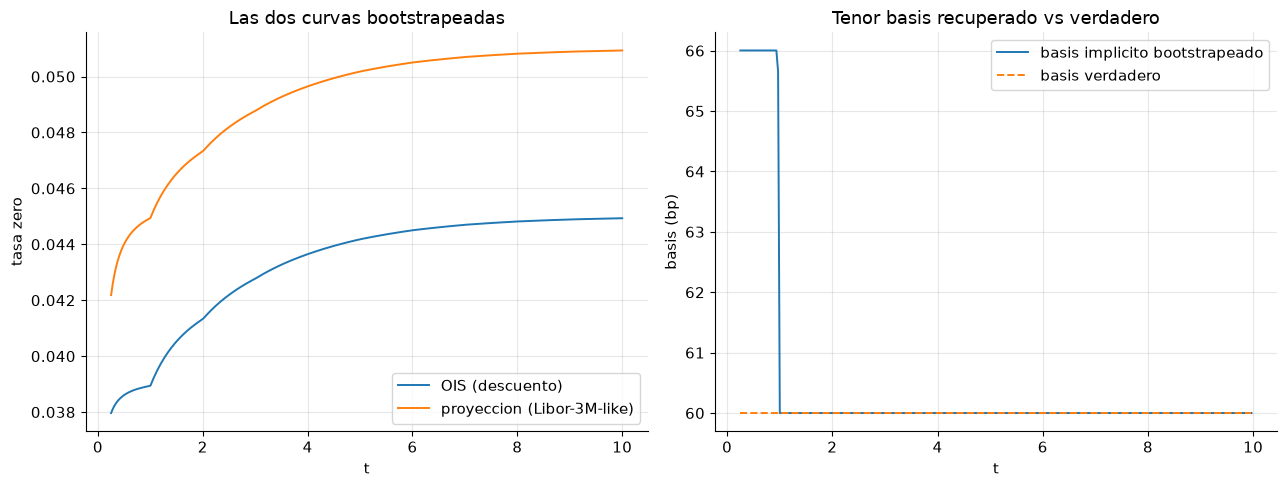

In [3]:
deposit_periods = [ql.Period(1, ql.Months)]
proj_deposit_period = ql.Period(3, ql.Months)   # nodo corto propio de la curva de proyeccion (Section 2)
tenors = list(range(1, 11))

dep_times0 = [day_count.yearFraction(eval_date, eval_date + p) for p in deposit_periods]
dep_rates0 = [(1.0 / ois_true_df(t) - 1.0) / t for t in dep_times0]

swap_dates = [eval_date + ql.Period(n, ql.Years) for n in tenors]
swap_times = [day_count.yearFraction(eval_date, d) for d in swap_dates]

ois_rates = [par_swap_rate(ois_true_df, np.array(swap_times[:n])) for n in range(1, len(tenors) + 1)]
t_ois, df_ois = bootstrap_single_curve(deposit_periods, dep_rates0, tenors, ois_rates, eval_date, day_count)
ois_curve = DiscountCurve(t_ois, df_ois)

# la curva de proyeccion necesita su PROPIO nodo corto -- sin el, extrapola constante hacia t->0
# y la tasa zero implicita (-ln(df)/t) diverge; el mismo tipo de error de "no cubrir el corto plazo"
proj_dep_time0 = day_count.yearFraction(eval_date, eval_date + proj_deposit_period)
proj_dep_rate0 = (1.0 / proj_true_df(proj_dep_time0) - 1.0) / proj_dep_time0
proj_dep_df0 = 1.0 / (1.0 + proj_dep_rate0 * proj_dep_time0)

proj_rates = [par_rate_dual_curve(proj_true_df, ois_true_df, swap_times[:n]) for n in range(1, len(tenors) + 1)]
t_proj_swaps, df_proj_swaps = bootstrap_projection_curve(tenors, proj_rates, ois_curve.df, eval_date, day_count)
t_proj = np.concatenate([[proj_dep_time0], t_proj_swaps])
df_proj = np.concatenate([[proj_dep_df0], df_proj_swaps])
proj_curve = DiscountCurve(t_proj, df_proj)

print(f"{'n':>4} | {'OIS rate':>10} | {'proj rate (3M-like)':>19} | {'basis (bp)':>10}")
print("-" * 52)
for n, K_ois, K_proj in zip(tenors, ois_rates, proj_rates):
    print(f"{n:>4} | {K_ois:>10.6%} | {K_proj:>19.6%} | {(K_proj-K_ois)*1e4:>10.1f}")

t_probe = 5.0
F_ois_probe = (ois_curve.df(t_probe - 1) / ois_curve.df(t_probe) - 1.0)
F_proj_probe = (proj_curve.df(t_probe - 1) / proj_curve.df(t_probe) - 1.0)
basis_implied = F_proj_probe - F_ois_probe
F_true_ois = (ois_true_df(t_probe - 1) / ois_true_df(t_probe) - 1.0)
F_true_proj = (proj_true_df(t_probe - 1) / proj_true_df(t_probe) - 1.0)
basis_true = F_true_proj - F_true_ois
print(f"\nEn t={t_probe}: basis implicito recuperado = {basis_implied:.6%}  vs  basis verdadero = {basis_true:.6%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
t_fine = np.linspace(max(t_ois[0], t_proj[0]) + 1e-6, 10.0, 300)  # ambas curvas con cobertura real
ax.plot(t_fine, -np.log(ois_curve.df(t_fine)) / t_fine, label="OIS (descuento)")
ax.plot(t_fine, -np.log(proj_curve.df(t_fine)) / t_fine, label="proyeccion (Libor-3M-like)")
ax.set_xlabel("t"); ax.set_ylabel("tasa zero"); ax.set_title("Las dos curvas bootstrapeadas")
ax.legend()

ax = axes[1]
f_ois_fine = -np.diff(np.log(ois_curve.df(t_fine))) / np.diff(t_fine)
f_proj_fine = -np.diff(np.log(proj_curve.df(t_fine))) / np.diff(t_fine)
ax.plot(t_fine[:-1], (f_proj_fine - f_ois_fine) * 1e4, label="basis implicito bootstrapeado")
f_true_ois_fine = -np.diff(np.log(ois_true_df(t_fine))) / np.diff(t_fine)
f_true_proj_fine = -np.diff(np.log(proj_true_df(t_fine))) / np.diff(t_fine)
ax.plot(t_fine[:-1], (f_true_proj_fine - f_true_ois_fine) * 1e4, "--", label="basis verdadero")
ax.set_xlabel("t"); ax.set_ylabel("basis (bp)"); ax.set_title("Tenor basis recuperado vs verdadero")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Demo 2 — el costo de ignorar el multi-curva

Si en cambio se descuenta con una sola curva (la de proyección, el error clásico pre-2008), ¿cuánto se equivoca el valor de un swap? Comparamos el valor presente de la pata flotante de un swap 5Y bajo el descuento correcto (OIS) contra el descuento ingenuo (proyección), con el basis sintético de este notebook.

In [4]:
n_demo = 5
times_demo = np.array(swap_times[:n_demo])
tau_demo = np.diff(np.concatenate([[0.0], times_demo]))
proj_dfs_demo = proj_curve.df(times_demo)
proj_dfs_prev_demo = np.concatenate([[1.0], proj_dfs_demo[:-1]])
forwards_demo = (proj_dfs_prev_demo / proj_dfs_demo - 1.0) / tau_demo

float_leg_correct = np.sum(tau_demo * forwards_demo * ois_curve.df(times_demo))
float_leg_naive = np.sum(tau_demo * forwards_demo * proj_curve.df(times_demo))

print(f"Pata flotante swap {n_demo}Y, nocional=1:")
print(f"  descuento correcto (OIS)         = {float_leg_correct:.6f}")
print(f"  descuento ingenuo (proyeccion)   = {float_leg_naive:.6f}")
print(f"  error relativo = {(float_leg_naive-float_leg_correct)/float_leg_correct:.4%}")

Pata flotante swap 5Y, nocional=1:
  descuento correcto (OIS)         = 0.226009
  descuento ingenuo (proyeccion)   = 0.222008
  error relativo = -1.7706%


## 4. Validación

1. **Bootstrapping OIS**: reprecia sus propias cotizaciones a `atol=1e-10` (idéntico al algoritmo de 5.2).
2. **Bootstrapping de proyección**: reprecia sus propias cotizaciones swap (con descuento OIS) a `atol=1e-10`.
3. **Basis recuperado**: vs el basis verdadero de las dos Nelson-Siegel, `rtol=5e-3`.
4. **Cross-check QuantLib**: ambas curvas contra `ql.PiecewiseLogLinearDiscount`, la de proyección construida con `SwapRateHelper(..., discountingCurve=ois_handle)`, discount factors en los nodos comunes, `atol=1e-7`.

In [5]:
# 1. OIS reprecia
for i, (K, t_n) in enumerate(zip(ois_rates, swap_times)):
    repriced = par_swap_rate(ois_curve.df, np.array(swap_times[:i + 1]))
    assert abs(repriced - K) < 1e-10
print("OIS: reprecia sus cotizaciones (atol 1e-10)")

# 2. proyeccion reprecia
for i, (K, t_n) in enumerate(zip(proj_rates, swap_times)):
    repriced = par_rate_dual_curve(proj_curve.df, ois_curve.df, swap_times[:i + 1])
    assert abs(repriced - K) < 1e-10
print("Proyeccion: reprecia sus cotizaciones con descuento OIS (atol 1e-10)")

# 3. basis recuperado
rel_err_basis = abs(basis_implied - basis_true) / abs(basis_true)
print(f"basis implicito vs verdadero: rel_err = {rel_err_basis:.4%} (rtol 5e-3? {rel_err_basis < 5e-3})")
assert rel_err_basis < 5e-3

# 4. QuantLib cross-check
helpers_ois = [ql.DepositRateHelper(ql.QuoteHandle(ql.SimpleQuote(dep_rates0[0])), deposit_periods[0], 0,
                                      ql.NullCalendar(), ql.Unadjusted, False, day_count)]
dummy_index = ql.IborIndex("dummy", ql.Period(1, ql.Years), 0, ql.USDCurrency(), ql.NullCalendar(),
                            ql.Unadjusted, False, day_count)
for n, K in zip(tenors, ois_rates):
    helpers_ois.append(ql.SwapRateHelper(ql.QuoteHandle(ql.SimpleQuote(K)), ql.Period(n, ql.Years),
                                           ql.NullCalendar(), ql.Annual, ql.Unadjusted, day_count, dummy_index))
curve_ois_ql = ql.PiecewiseLogLinearDiscount(eval_date, helpers_ois, day_count)
curve_ois_ql.enableExtrapolation()
ois_handle = ql.YieldTermStructureHandle(curve_ois_ql)

helpers_proj = []
for n, K in zip(tenors, proj_rates):
    helpers_proj.append(ql.SwapRateHelper(ql.QuoteHandle(ql.SimpleQuote(K)), ql.Period(n, ql.Years),
                                            ql.NullCalendar(), ql.Annual, ql.Unadjusted, day_count, dummy_index,
                                            ql.QuoteHandle(), ql.Period(0, ql.Days), ois_handle))
curve_proj_ql = ql.PiecewiseLogLinearDiscount(eval_date, helpers_proj, day_count)
curve_proj_ql.enableExtrapolation()

max_diff_ois = max(abs(df_ois[len(deposit_periods) + n - 1] - curve_ois_ql.discount(swap_dates[n - 1]))
                    for n in tenors)
max_diff_proj = max(abs(proj_curve.df(t_n) - curve_proj_ql.discount(d_n)) for t_n, d_n in zip(swap_times, swap_dates))
print(f"\nmax|diff| OIS vs QuantLib = {max_diff_ois:.2e} (atol 1e-7? {max_diff_ois < 1e-7})")
print(f"max|diff| proyeccion vs QuantLib = {max_diff_proj:.2e} (atol 1e-7? {max_diff_proj < 1e-7})")
assert max_diff_ois < 1e-7
assert max_diff_proj < 1e-7

print()
print("Validacion completa: 4/4 dentro de tolerancia.")

OIS: reprecia sus cotizaciones (atol 1e-10)
Proyeccion: reprecia sus cotizaciones con descuento OIS (atol 1e-10)
basis implicito vs verdadero: rel_err = 0.0000% (rtol 5e-3? True)

max|diff| OIS vs QuantLib = 9.26e-14 (atol 1e-7? True)
max|diff| proyeccion vs QuantLib = 2.04e-13 (atol 1e-7? True)

Validacion completa: 4/4 dentro de tolerancia.


## Referencias

- Ametrano, F. & Bianchetti, M. (2009). *Bootstrapping the Illiquidity: Multiple Yield Curves Construction for Market Coherent Forward Curves Estimation*.
- Ametrano, F. & Bianchetti, M. (2013). *Everything You Always Wanted to Know About Multiple Interest Rate Curve Bootstrapping but Were Afraid to Ask*.
- Hull, J.C. *Options, Futures, and Other Derivatives*, 10th ed., cap. 9 (OIS discounting).
- Mercurio, F. (2010). *A LIBOR Market Model with Stochastic Basis*. Bloomberg Quantitative Research Paper.